In [1]:
print("Hello This is Abdul Momin - AI Cyber Project Started 🚀")

Hello This is Abdul Momin - AI Cyber Project Started 🚀


In [2]:
%pip install pandas scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
data = pd.read_csv("../data/network_traffic.csv")
data.head()

,No.,Time,Source,Destination,Protocol,Length,Info
0,1,0.000000,192.168.0.106,224.0.0.251,MDNS,320,"Standard query response 0x0000 PTR, cache flus..."
1,2,0.101576,192.168.0.106,224.0.0.251,MDNS,456,"Standard query response 0x0000 TXT, cache flus..."
2,3,0.203514,192.168.0.106,224.0.0.251,MDNS,142,Standard query 0x0000 PTR _apple-mobdev._tcp.l...
3,4,0.305974,192.168.0.106,224.0.0.251,MDNS,139,"Standard query 0x0000 PTR _ni-rt._tcp.local, ""..."
4,5,0.716755,TPLink_a7:cc:e1,Broadcast,ARP,42,Who has 192.168.0.100? Tell 192.168.0.1


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 113949 entries, 0 to 113948
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   No.          113949 non-null  int64  
 1   Time         113949 non-null  float64
 2   Source       113949 non-null  str    
 3   Destination  113949 non-null  str    
 4   Protocol     113949 non-null  str    
 5   Length       113949 non-null  int64  
 6   Info         113949 non-null  str    
dtypes: float64(1), int64(2), str(4)
memory usage: 6.1 MB


In [5]:
data.describe()

,No.,Time,Length
count,113949.000000,113949.000000,113949.000000
mean,56975.000000,97.159782,848.209611
std,32894.387249,83.475438,615.102315
min,1.000000,0.000000,42.000000
25%,28488.000000,31.135769,90.000000
50%,56975.000000,52.531972,1234.000000
75%,85462.000000,130.949552,1292.000000
max,113949.000000,329.825917,16440.000000


In [6]:
data.columns

Index(['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info'], dtype='str')

In [7]:
data = data.drop(['No.', 'Info'], axis=1)
data.head()

,Time,Source,Destination,Protocol,Length
0,0.000000,192.168.0.106,224.0.0.251,MDNS,320
1,0.101576,192.168.0.106,224.0.0.251,MDNS,456
2,0.203514,192.168.0.106,224.0.0.251,MDNS,142
3,0.305974,192.168.0.106,224.0.0.251,MDNS,139
4,0.716755,TPLink_a7:cc:e1,Broadcast,ARP,42


In [8]:
data['Protocol'] = data['Protocol'].astype('category').cat.codes
data.head()

,Time,Source,Destination,Protocol,Length
0,0.000000,192.168.0.106,224.0.0.251,8,320
1,0.101576,192.168.0.106,224.0.0.251,8,456
2,0.203514,192.168.0.106,224.0.0.251,8,142
3,0.305974,192.168.0.106,224.0.0.251,8,139
4,0.716755,TPLink_a7:cc:e1,Broadcast,0,42


In [9]:
data = data.drop(['Source', 'Destination'], axis=1)
data.head()

,Time,Protocol,Length
0,0.000000,8,320
1,0.101576,8,456
2,0.203514,8,142
3,0.305974,8,139
4,0.716755,0,42


In [10]:
from sklearn.ensemble import IsolationForest

In [11]:
model = IsolationForest(contamination=0.01)

In [12]:
model.fit(data)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [13]:
data['Anomaly'] = model.predict(data)
data.head()

,Time,Protocol,Length,Anomaly
0,0.000000,8,320,1
1,0.101576,8,456,1
2,0.203514,8,142,1
3,0.305974,8,139,1
4,0.716755,0,42,-1


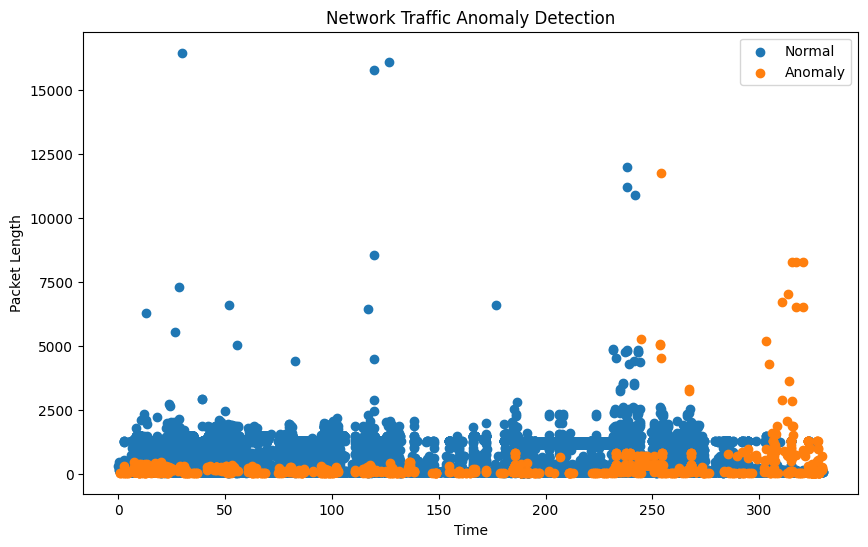

In [14]:
import matplotlib.pyplot as plt

# Separate data
normal = data[data['Anomaly'] == 1]
anomaly = data[data['Anomaly'] == -1]

# Plot
plt.figure(figsize=(10,6))
plt.scatter(normal['Time'], normal['Length'], label='Normal')
plt.scatter(anomaly['Time'], anomaly['Length'], label='Anomaly')

plt.xlabel("Time")
plt.ylabel("Packet Length")
plt.title("Network Traffic Anomaly Detection")
plt.legend()

plt.show()

In [15]:
anomaly_data = data[data['Anomaly'] == -1]
anomaly_data.to_csv("anomalies.csv", index=False)

In [16]:
anomaly_data.head(10)

,Time,Protocol,Length,Anomaly
4,0.716755,0,42,-1
5,0.716755,0,42,-1
10,1.741168,0,42,-1
11,2.662411,0,42,-1
12,2.662411,0,42,-1
15,2.733764,2,68,-1
16,2.734065,2,68,-1
19,2.738014,2,290,-1
20,2.738308,2,116,-1
48,2.975984,2,76,-1


In [17]:
data['Anomaly'].value_counts()

Anomaly
 1    112809
-1      1140
Name: count, dtype: int64

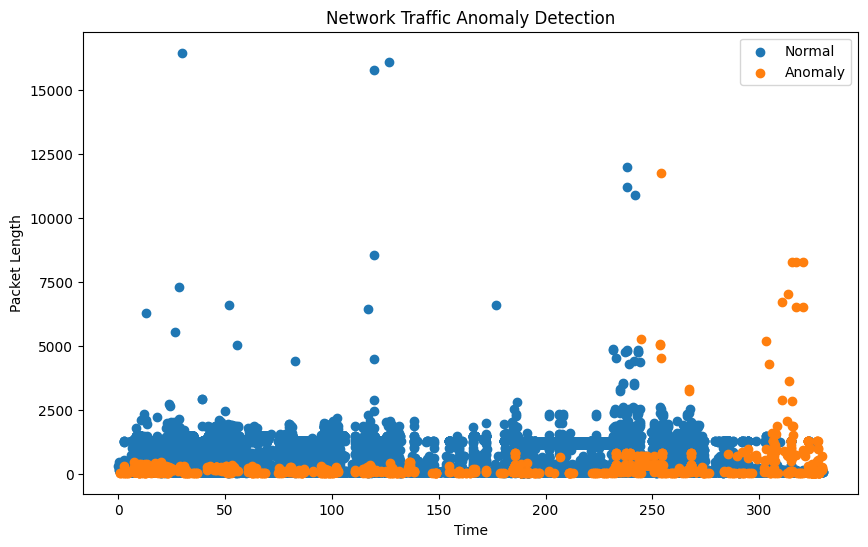

In [18]:
import matplotlib.pyplot as plt

# Separate data
normal = data[data['Anomaly'] == 1]
anomaly = data[data['Anomaly'] == -1]

# Plot
plt.figure(figsize=(10,6))
plt.scatter(normal['Time'], normal['Length'], label='Normal')
plt.scatter(anomaly['Time'], anomaly['Length'], label='Anomaly')

plt.xlabel("Time")
plt.ylabel("Packet Length")
plt.title("Network Traffic Anomaly Detection")
plt.legend()

plt.show()

In [19]:
anomaly_data = data[data['Anomaly'] == -1]
anomaly_data.to_csv("anomalies.csv", index=False)

In [20]:
anomaly_data.head(10)

,Time,Protocol,Length,Anomaly
4,0.716755,0,42,-1
5,0.716755,0,42,-1
10,1.741168,0,42,-1
11,2.662411,0,42,-1
12,2.662411,0,42,-1
15,2.733764,2,68,-1
16,2.734065,2,68,-1
19,2.738014,2,290,-1
20,2.738308,2,116,-1
48,2.975984,2,76,-1


In [21]:
anomaly_data['Protocol'].value_counts()

Protocol
2     543
0     229
4     153
10     61
8      34
3      30
7      28
15     25
9      12
5      10
16      8
1       4
6       3
Name: count, dtype: int64

In [22]:
anomaly_data['Length'].value_counts().head(10)

Length
42     229
356    147
46      28
76      27
80      22
75      20
78      19
808     18
110     17
86      13
Name: count, dtype: int64

In [23]:
anomaly_data.to_csv("Outputs/anomalies.csv", index=False)

OSError: Cannot save file into a non-existent directory: 'Outputs'

In [24]:
import os
os.getcwd()

"c:\\Users\\Momin's Pc\\Desktop\\AI-CYBER-PROJECT\\Notebooks"

In [25]:
import os
os.path.exists("Outputs")

False

In [26]:
import os
print(os.listdir())

['anomalies.csv', 'anomaly_detection.ipynb']


In [27]:
anomaly_data.to_csv("../Outputs/anomalies.csv", index=False)

In [28]:
import os

file_path = os.path.join("..", "Outputs", "anomalies.csv")
anomaly_data.to_csv(file_path, index=False)

print("Saved successfully!")

Saved successfully!


In [29]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']